# Breast Cancer Classification

## Objective

Build a machine learning model that predicts whether a tumor is malignant(cancerous) or benign (non-cancerous) based on tumor measurements.

## Business Value

Early identification of malignant tumors can assist doctors in prioritizing diagnosis and treatment.

----
```
Business Problem
        ↓
Data
        ↓
Features
        ↓
Target
        ↓
Train/Test Split
        ↓
Scaling
        ↓
Logistic Regression
        ↓
Probabilities
        ↓
Predictions
        ↓
Evaluation
        ↓
Interpretation

## **1. Load Dataset**

In [14]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

#creating dataframe

df = pd.DataFrame(
    data.data,
    columns = data.feature_names
)

df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [15]:
print(df.shape)
print(df.columns)

(569, 31)
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')


- How many patients do we have?
    > We essentially have 569 samples, which means the total number of patients is 569

- How many features do we have?
    > We have 31 features, including the target variable

- What is the target column?
    > The target column is the classification of whether the tumor is cancerous or not.
    

---
## **2. Understanding the Dataset**

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

- Any missing values?
    > There are no missing values, as we can observe that each feature has 569 non-null values.

- Are features numerical?
   > Yes, all the features are numerical. 

- Do we need data cleaning?
    > No major data cleaning is required because there are no missing values and all features are already numerical.

In [17]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


- What are the ranges?

> Some features have:
  > - small ranges (0–0.1)
  >  - ranges (10–50)
  > - very large ranges (100–2500)



----
## **3. Understanding the Target**

In [18]:
print(data.target_names)
print(df["target"].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


> In sklearn datasets:
   > - 0 → first label
   >- 1 → second label

> -  We have 212 cases of malignant(cancerous tumour) 
> - And 357  cases of benign(non - cancerous tumour) 

----
## **4. Exploratory Analysis**

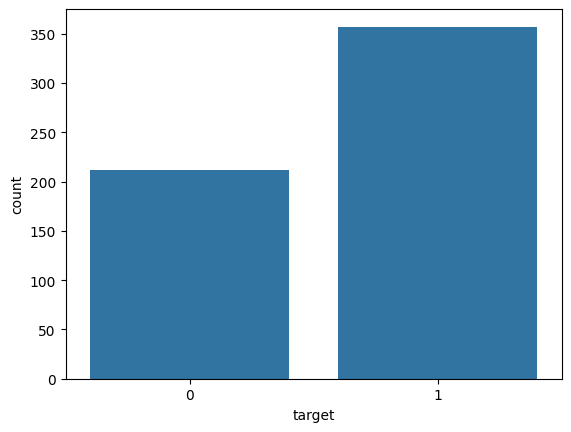

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    x = "target",
    data = df
)

plt.show()

- Is the dataset balanced?

### **investigating a feature : mean radius**

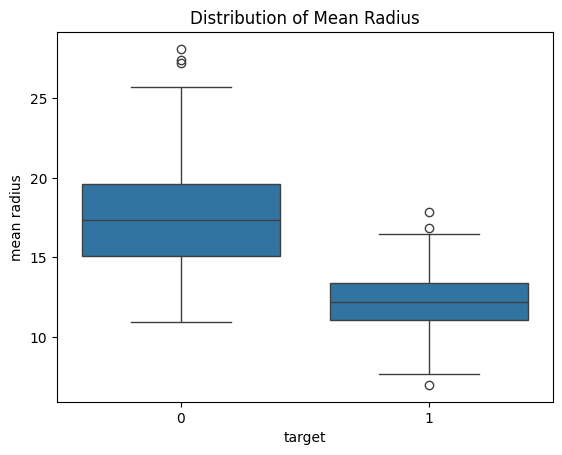

In [20]:
sns.boxplot(
    x="target",
    y="mean radius",
    data=df
)
plt.title("Distribution of Mean Radius")
plt.show()


> Do malignant tumors have larger radius?

## **5. Define X and y**

In [21]:
X = df.drop("target", axis = 1)
y = df["target"]

---
## **6. Train-Test Split**

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state = 42)

---
## **7. Feature Scaling**

Why?

- Because some features are much larger than others.

Example:

Feature	Range

Mean Radius	5–30

Area	150–2500

- Without scaling, "Area" would dominate simply because of its larger numeric values.

- Scaling converts each feature to roughly:

    - Mean = 0
    - Standard deviation = 1

- This makes features comparable and is especially important for models like Logistic Regression.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

----
## **8. Train Logistic Regression**

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled , y_train)

LogisticRegression()

## **9. Predictions**

In [33]:
# Probabilities
y_prob = model.predict_proba(X_test_scaled)

# Final class predictions
y_pred = model.predict(X_test_scaled)

#print(y_prob)

#### **predict_proba() → "How confident is the model?"**

In [26]:
prob_df = pd.DataFrame(
    y_prob[:5],
    columns=["Malignant_Prob", "Benign_Prob"]
)

prob_df

,Malignant_Prob,Benign_Prob
0,0.072230,0.927770
1,0.999991,0.000009
2,0.995392,0.004608
3,0.000173,0.999827
4,0.000021,0.999979


**Interpretation:**

- **For patient 1:**

    - The model assigns 7.2% probability to the tumor being malignant.
    - It assigns 92.8% probability to the tumor being benign.
    - Since benign probability is much higher, the model predicts the tumor as benign (class 1).

---
- **For patient 2:**

    - The model assigns 99% probability to the tumor being malignant.
    - It assigns 0 probability to the tumor being benign.
    - Since malignant probability is much higher, the model predicts the tumor as malignant (class 0).
      

---
## **10. Evaluation**

In [27]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,
    y_pred)

0.9824561403508771

In [28]:
from sklearn.metrics import confusion_matrix

confusion_matrix(
    y_test,
    y_pred
)

array([[41,  2],
       [ 0, 71]])

In [29]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)



,Feature,Coefficient
15,compactness error,0.682491
19,fractal dimension error,0.616230
5,mean compactness,0.540164
18,symmetry error,0.500425
8,mean symmetry,0.236119
11,texture error,0.188877
16,concavity error,0.175275
9,mean fractal dimension,0.075921
25,worst compactness,0.016110
4,mean smoothness,-0.071667


In [31]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(569, 30)
(455, 30)
(114, 30)


-------
## 📊 Model Evaluation & Interpretation

**1. Dataset Overview**

- The dataset contains 569 samples of breast cancer data with 30 numerical features describing tumor characteristics.

- The target variable is:

    - 0 = Malignant (Cancerous)
    - 1 = Benign (Non-cancerous)

- The dataset was split into:

    - Training set: 455 samples
    - Test set: 114 samples

- The model was evaluated only on the test set (unseen data).

---
**2. Model Performance**

- The Logistic Regression model achieved **accuracy**: 98.25%

- This means the model correctly classified 112 out of 114 test samples.

---
**3. Confusion Matrix Interpretation**

Confusion Matrix:

[[41  2]
 [ 0 71]]

- Breakdown:

    - True Positives (TP = 41): Correctly predicted malignant tumors.
    - True Negatives (TN = 71): Correctly predicted benign tumors.
    - False Negatives (FN = 2): Malignant tumors incorrectly predicted as benign (missed cancer cases).
    - False Positives (FP = 0): No benign tumors were incorrectly predicted as malignant.

---
**4. Key Insights**

- The model performs very well overall with high accuracy (98.25%).

- It has perfect precision for malignant predictions, meaning whenever it predicts cancer, it is always correct.

- However, it misses 2 malignant cases, which is important because in medical diagnosis, false negatives are critical errors.

---
**5. Medical Interpretation**

In a healthcare setting:

- False Negatives (missed cancer cases) are more dangerous than false positives.
- The model successfully detects most cancer cases but misses a small number (2 cases).

- This means the model is highly reliable but should be further optimized if used in real clinical decision-making, especially to reduce false negatives.

---
**6. Final Conclusion**

The Logistic Regression model provides a strong baseline for breast cancer classification with:

- High accuracy (98.25%)
- Excellent ability to detect benign cases
- Very low number of misclassifications

- Overall, the model demonstrates strong predictive performance and good generalization on unseen data, making it a solid foundation for further improvement using more advanced models or threshold tuning.